0.7853968253968254
0.7555555555555555
Intercept: [-4.1647707]
Coefficients: [[ 5.19399361e-01  6.73220724e-05 -4.87838668e-01  7.39030838e-01
  -2.02700807e-01 -3.22871882e-01 -2.12770815e-01  6.20616637e-01
  -5.11255152e-02 -1.26765273e-01  4.97594234e-01  2.21652375e-02
   1.96854430e-01 -6.68419944e-01 -1.62728640e-01  4.88767109e-01
   5.04871048e-02 -5.77752843e-01 -2.76478327e-01  2.76825312e-01
  -2.26158966e-01]]
Confusion matrix:
 [[476  92]
 [ 37  70]]
Precision: 0.43209876543209874
Recall: 0.6542056074766355
F1-score: 0.520446096654275


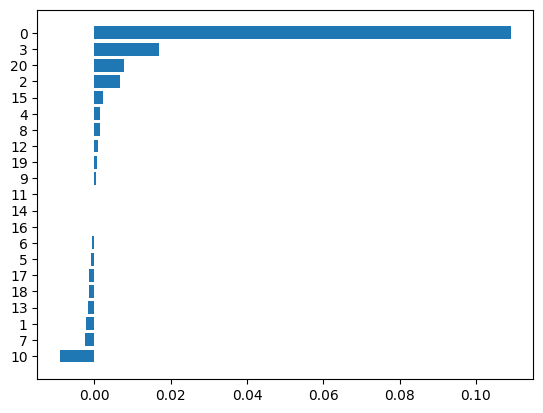

[-9.03703704e-03 -2.37037037e-03 -2.22222222e-03 -1.62962963e-03
 -1.48148148e-03 -1.33333333e-03 -8.88888889e-04 -5.92592593e-04
 -1.48148148e-04 -1.11022302e-17  0.00000000e+00  2.96296296e-04
  7.40740741e-04  8.88888889e-04  1.33333333e-03  1.33333333e-03
  2.22222222e-03  6.66666667e-03  7.70370370e-03  1.68888889e-02
  1.09185185e-01]
0.8006349206349206
0.7733333333333333
Intercept: [-3.85974903]
Coefficients: [[ 0.53304894 -0.5161893  -0.25935708  0.71270381  0.50001431]]
Confusion matrix:
 [[495  73]
 [ 40  67]]
Precision: 0.4785714285714286
Recall: 0.6261682242990654
F1-score: 0.5425101214574898


In [176]:
#DV: rating row[8]
#IDVs: abv - row[6], raters - row[9], text - row[12]-row[30]
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance

#import data from CSVs
data = []
files=["../2_Database/TopBeerData.csv","../2_Database/GoodBeerData.csv","../2_Database/RestBeerData.csv"]
for i in range (0,len(files)):
    with open(files[i],"r",encoding="utf-8") as file:
        reader = csv.reader(file)
        for row in reader:
            row.append(i)
            data.append(row)

all_numeric_data = []
numeric_data = []
for row in data[1:]:  # ignore heading
    numeric_data.append([
        float(row[6]),  # 0 abv
        float(row[9]),   # 1 raters
        float(row[12]),  # 2 malt
        float(row[13]),  # 3 hops
        float(row[14]),  # 4 chocolate
        float(row[15]),  # 5 german
        float(row[16]),  # 6 banana
        float(row[17]),  # 7 vanilla
        float(row[18]),  # 8 caramel
        float(row[19]),  # 9 yeast
        float(row[20]),  # 10 fruit
        float(row[21]),  # 11 whiskey
        float(row[22]),  # 12 rhum
        float(row[23]),  # 13 alcohol
        float(row[24]),  # 14 gluten
        float(row[25]),  # 15 barrel
        float(row[26]),  # 16 rye
        float(row[27]),  # 17 barley
        float(row[28]),  # 18 cocoa
        float(row[29]),  # 19 small/lower
        float(row[30]),  # 20 big/upper
        float(row[31]) #id 0-Top, 1-Good, 2-Rest need to stay the last coloumn
    ])
numeric_data = np.array(numeric_data)
all_numeric_data.append(numeric_data)

combined = np.vstack(all_numeric_data)

#IDVs + DV def
#only to use top beers (0) OR good beers (1)
mask = (combined[:, -1] == 1) | (combined[:, -1] == 2)
filtered_data = numeric_data[mask]
X = filtered_data[:, :-1]
y = filtered_data[:, -1] == 1 #true if 1, else otherwise

# train-test split randomly
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# model
model = LogisticRegression(
    #penalty = "l1",
    #solver = "saga",
    C=0.1,
    max_iter=5000,
    class_weight="balanced"
)
# train
model.fit(X_train, y_train)

# prediction
treshold = 0.58
#y_prob = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = y_prob > treshold
#print(y_pred)
# accuracy
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("Precision:", precision) #higher is better
print("Recall:", recall)
print("F1-score:", (2*precision*recall)/(precision+recall))

#permutation of features to eliminate features
baseline = model.score(X_test, y_test)
X_test_perm = X_test.copy()
X_test_perm[:, i] = np.random.permutation(X_test_perm[:, i])
score_perm = model.score(X_test_perm, y_test)
importance_i = baseline - score_perm

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)
result.importances_mean
result.importances_std
sorted_idx = result.importances_mean.argsort()

plt.barh(
    range(X.shape[1]),
    result.importances_mean[sorted_idx]
)

plt.yticks(range(X.shape[1]), sorted_idx)
plt.show()
print(result.importances_mean[sorted_idx])

top_idx = np.argsort(result.importances_mean)[-5:] #based on the graph only the top features are to be used, others are just confusion
X_train_sel = X_train[:, top_idx]
X_test_sel = X_test[:, top_idx]
model.fit(X_train_sel, y_train)

# prediction
treshold2 = 0.63
y_prob_sel = model.predict_proba(X_test_sel)[:, 1]
y_pred_sel = y_prob_sel > treshold2
# accuracy
print(model.score(X_train_sel, y_train))
print(model.score(X_test_sel, y_test))

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
cm = confusion_matrix(y_test, y_pred_sel)
print("Confusion matrix:\n", cm)
precision = precision_score(y_test, y_pred_sel)
recall = recall_score(y_test, y_pred_sel)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", (2*precision*recall)/(precision+recall))

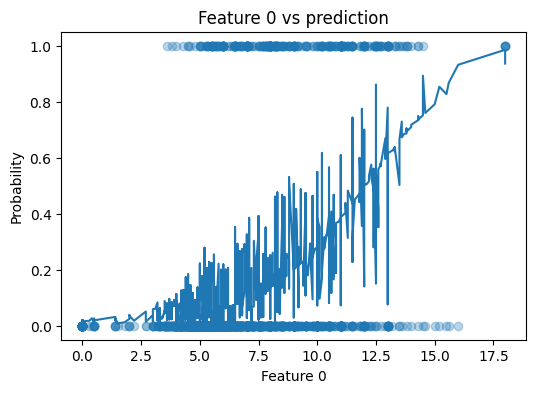

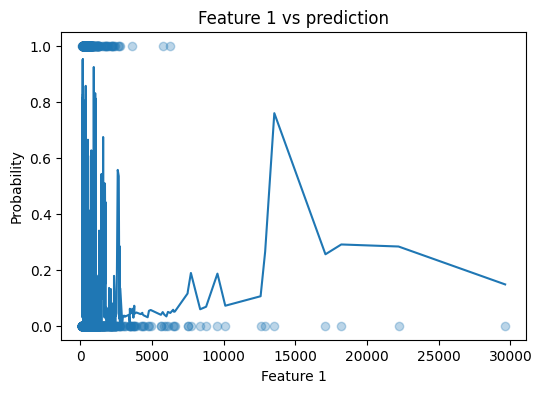

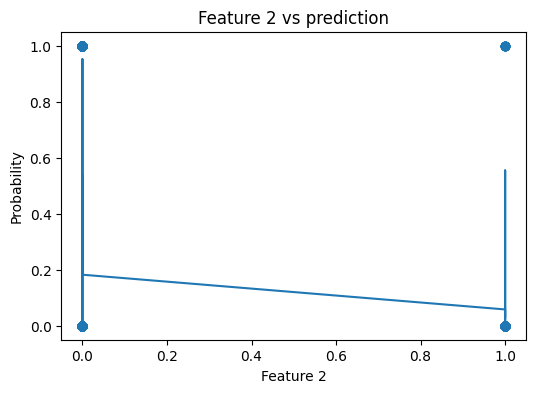

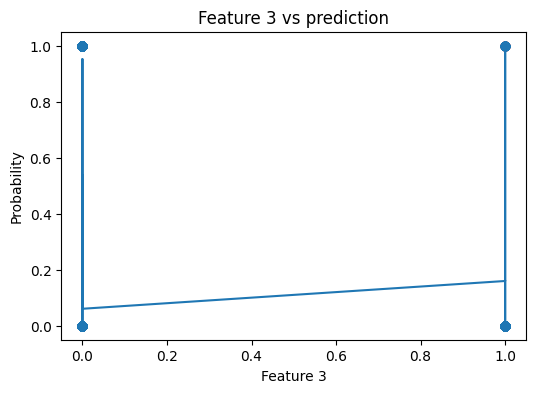

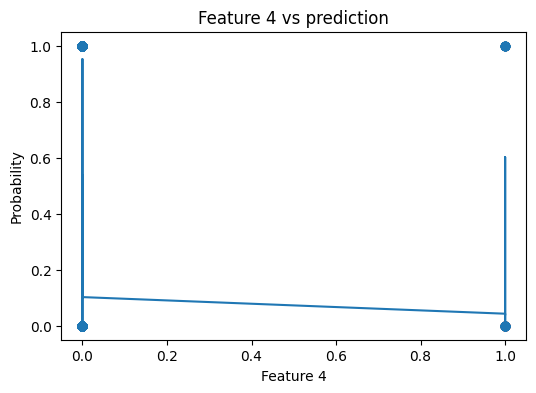

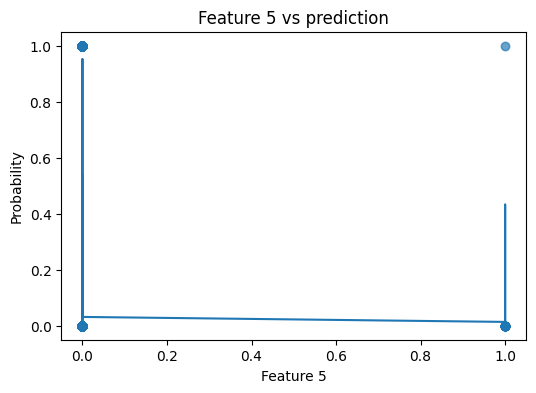

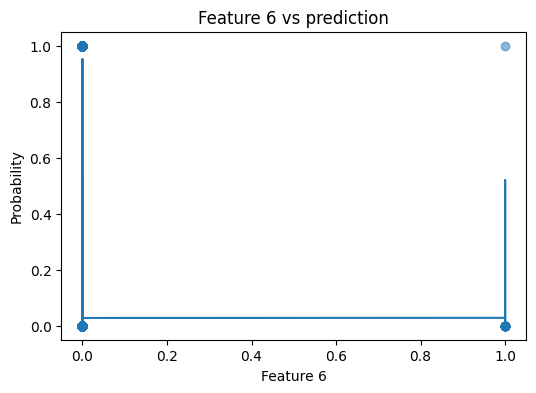

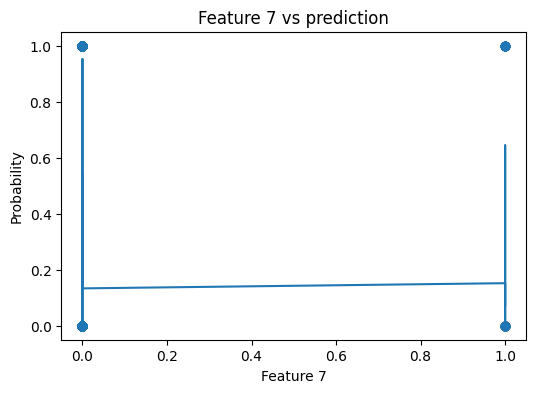

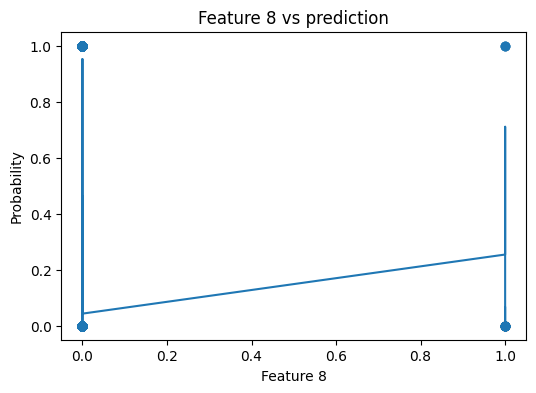

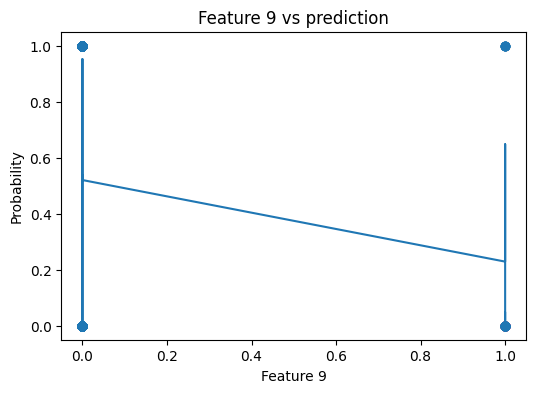

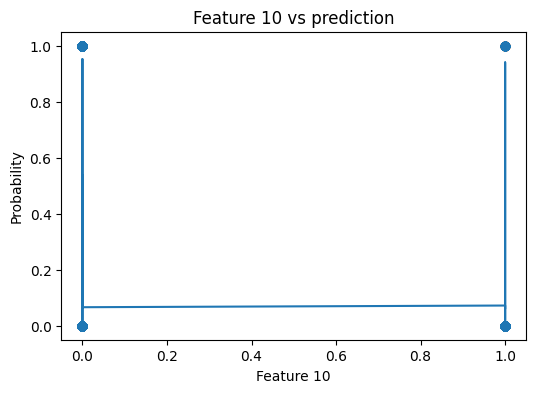

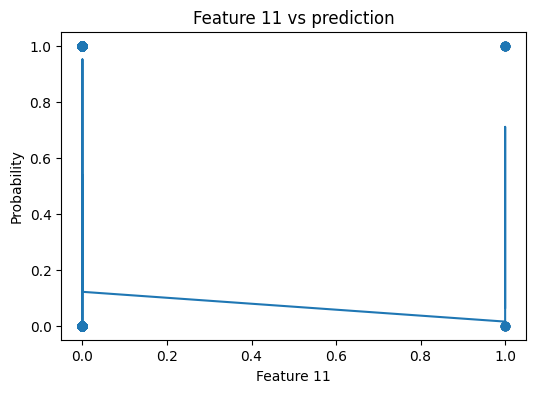

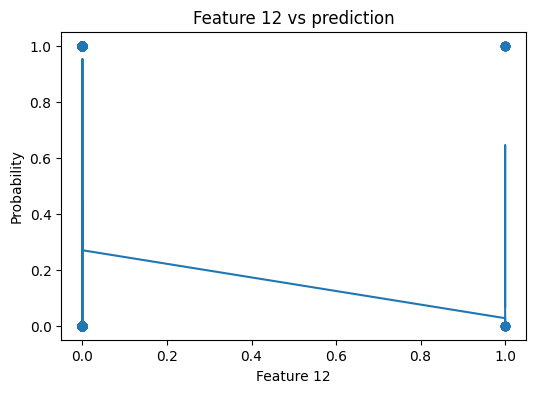

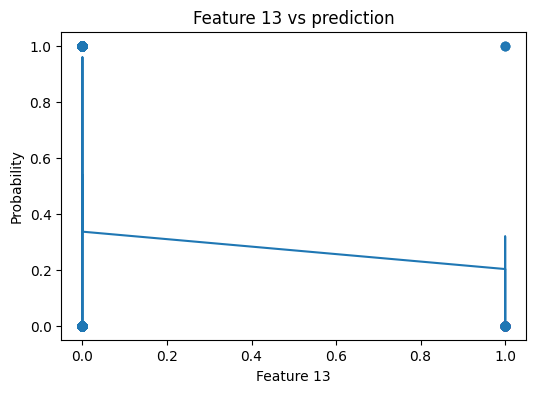

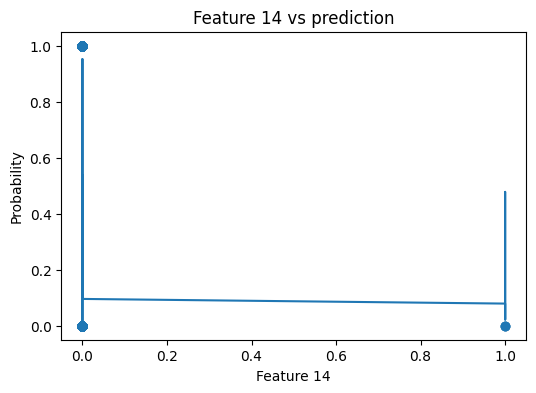

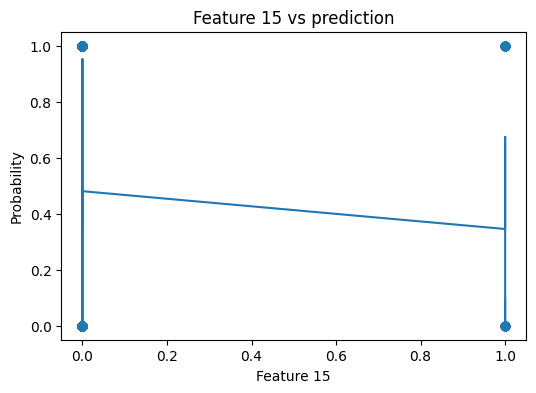

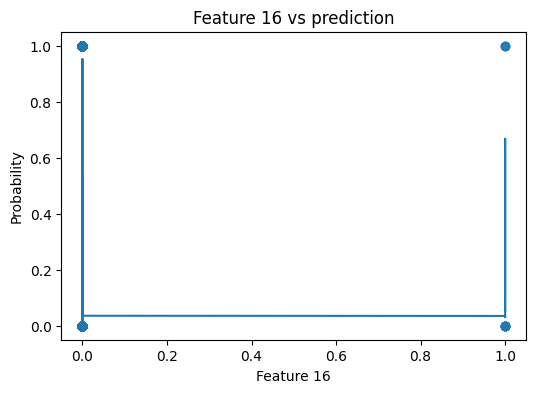

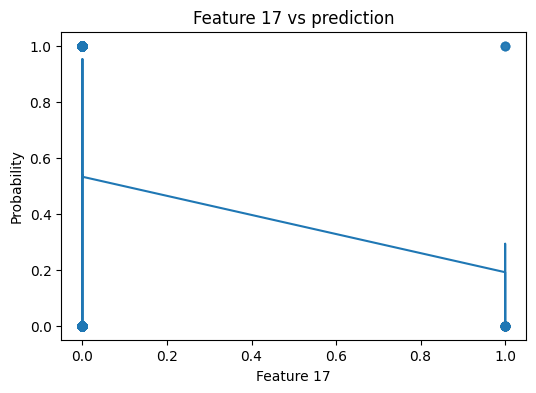

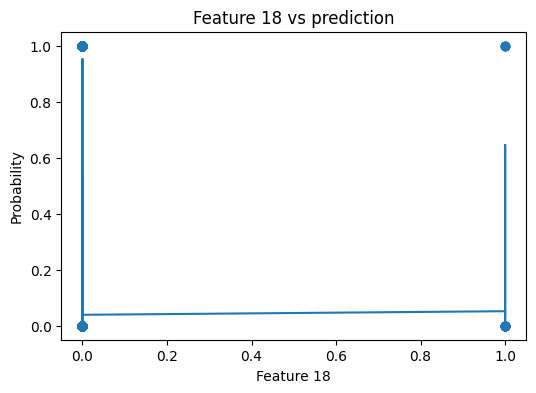

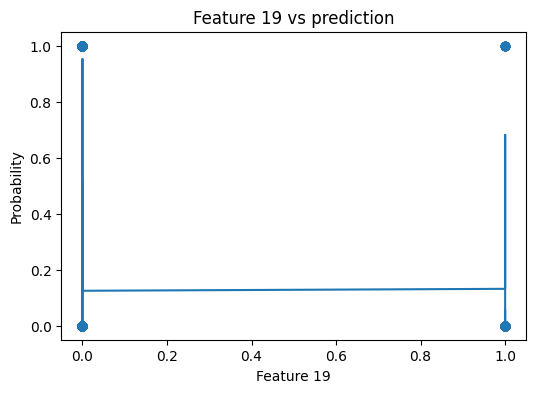

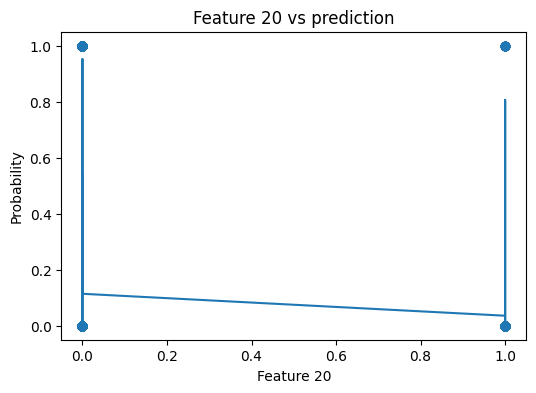

In [177]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# modell
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

n_features = X.shape[1]

for i in range(n_features):

    x_feature = X[:, i]

    # scatter
    plt.figure(figsize=(6,4))
    plt.scatter(x_feature, y, alpha=0.3)

    # rendezés a szép görbéhez
    idx = np.argsort(x_feature)

    x_sorted = x_feature[idx]

    # teljes X másolása
    X_temp = X.copy()

    # csak az i-edik feature változik
    X_temp[:, i] = x_sorted

    # valószínűségek
    y_prob = model.predict_proba(X_temp)[:, 1]

    # görbe
    plt.plot(x_sorted, y_prob)

    plt.xlabel(f"Feature {i}")
    plt.ylabel("Probability")
    plt.title(f"Feature {i} vs prediction")

    plt.show()